In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [48]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("enrique4/activity-recognition-with-accelerometer-and-sound")

print("Path to dataset files:", path)

data = pd.read_csv(path + '/features.csv')

data.head()

Path to dataset files: /Users/hp/.cache/kagglehub/datasets/enrique4/activity-recognition-with-accelerometer-and-sound/versions/1


,userid,label,v1_mfcc1,v1_mfcc2,v1_mfcc3,v1_mfcc4,v1_mfcc5,v1_mfcc6,v1_mfcc7,v1_mfcc8,...,v2_maxX,v2_maxY,v2_maxZ,v2_corXY,v2_corXZ,v2_corYZ,v2_meanMagnitude,v2_sdMagnitude,v2_auc,v2_meanDif
0,user1,watch_tv,120.078886,3.025171,0.390508,-1.777848,-9.216060,-6.567632,-9.918761,-9.145534,...,0.097412,1.088135,0.227051,0.900163,-0.729511,-0.863478,1.014805,0.060424,70.021543,-0.000364
1,user1,watch_tv,130.243139,2.552278,-6.457879,-7.440159,-3.070106,-3.475476,-5.718819,-2.878174,...,0.703613,1.424805,0.818115,-0.210431,0.319599,-0.722541,1.005713,0.162644,79.451303,-0.006234
2,user1,watch_tv,122.259209,1.970267,-8.980575,-10.222030,-3.564994,-2.496906,-5.584900,-6.730588,...,0.312500,0.972656,-0.070312,-0.018862,-0.093852,-0.305722,1.002809,0.006100,77.216317,0.000019
3,user1,watch_tv,122.609566,3.188740,-7.049397,-10.569875,-0.220824,-0.649459,-4.975825,-6.856288,...,0.349854,1.020020,-0.053223,0.492439,0.273064,-0.023051,1.002878,0.021292,75.215866,-0.000023
4,user1,watch_tv,121.393023,1.338798,-8.706183,-8.654997,-4.935310,-3.401656,-5.031361,-7.957924,...,0.322266,0.955078,-0.076904,-0.226296,-0.217439,-0.053895,1.003427,0.002849,71.243346,-0.000083


__1. Dataset Exploration__

In [49]:
user_row_count = data.groupby('userid').count()
print(user_row_count['label'])
print('Total Users: ', len(user_row_count))
print('Total Records ', len(data))

userid
user1    466
user2    466
user3    454
Name: label, dtype: int64
Total Users:  3
Total Records  1386


The home-tasks data were collected by 3 individuals. They were 1 female and
2 males with ages ranging from 25 to 30. The subjects were asked to perform
7 home-task activities including: mop floor, sweep floor, type on computer keyboard, brush teeth, wash hands, eat chips and watch TV. The eat chips activity
was conducted with a bag of chips. Each individual performed each activity for
approximately 3 minutes. If the activity lasted less than 3 minutes, an additional
trial was conducted until the 3 minutes were completed. The volunteers used a
wrist-band (Microsoft Band 2) and a smartphone (Sony XPERIA) to collect the
data.

In [50]:
summary_table = {
    'Users': [len(user_row_count)],
    'Days per participant (21 minutes each, 3 minutes per each activity, 7 activities)':[0.01458333333],
    'Demographic Diversity (Age and Gender)': ['2 males and 1 female, ages: 25-30'],
    'Total Labels': [f'{len(data)}, {len(data)/len(user_row_count)} per user']
}
summary_table = pd.DataFrame(summary_table)
summary_table

,Users,"Days per participant (21 minutes each, 3 minutes per each activity, 7 activities)",Demographic Diversity (Age and Gender),Total Labels
0,3,0.014583,"2 males and 1 female, ages: 25-30","1386, 462.0 per user"


In [51]:
pd.set_option('display.max_rows', None)
act_by_subject = data.groupby(['userid', 'label']).count()
act_by_subject['v2_meanDif']

userid  label           
user1   brush_teeth          59
        eat_chips           153
        mop_floor            56
        sweep                47
        type_on_keyboard     49
        wash_hands           36
        watch_tv             66
user2   brush_teeth          57
        eat_chips            65
        mop_floor            63
        sweep                68
        type_on_keyboard     63
        wash_hands           79
        watch_tv             71
user3   brush_teeth          64
        eat_chips            64
        mop_floor            62
        sweep                63
        type_on_keyboard     67
        wash_hands           65
        watch_tv             69
Name: v2_meanDif, dtype: int64

__2. Annotated Signal Exploration__

Does the data have missing values?  False


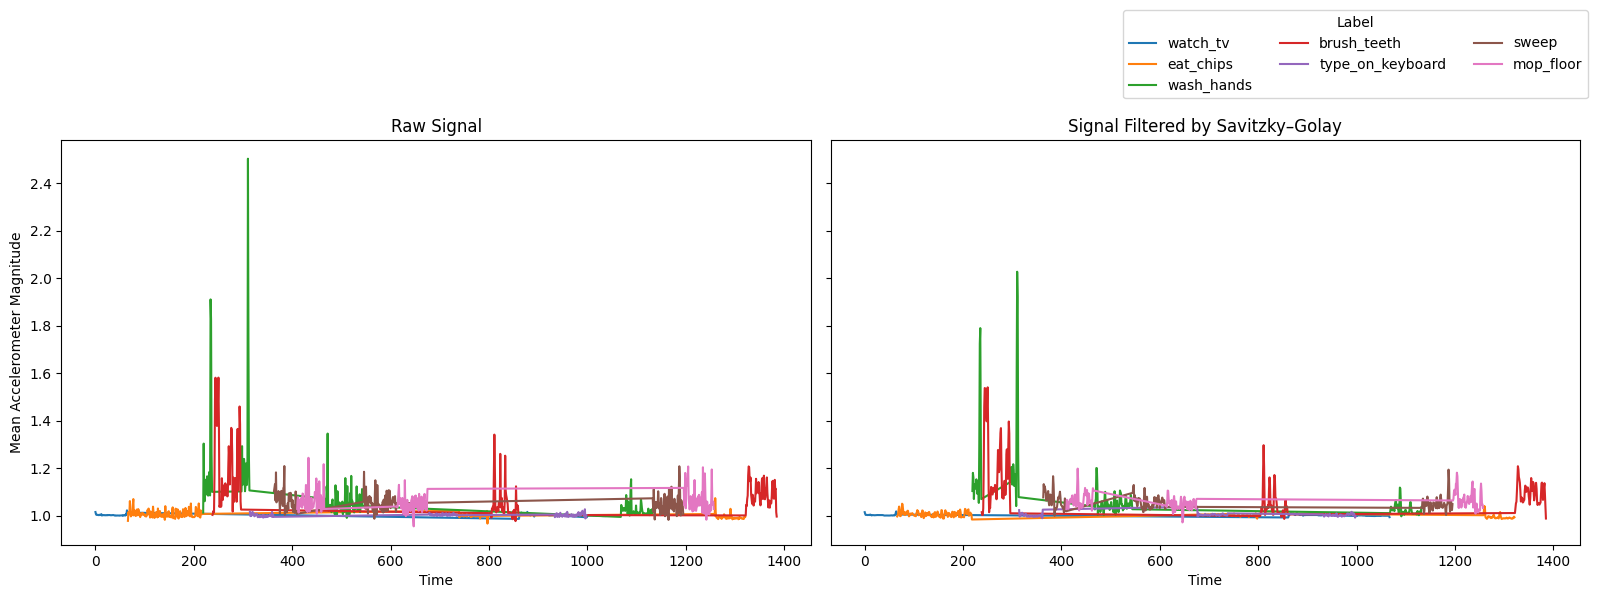

In [52]:
from scipy.signal import savgol_filter

has_missing_values = data.isna().any().any()
print('Does the data have missing values? ', has_missing_values)

filt = savgol_filter(data['v2_meanMagnitude'], window_length=5, polyorder=2)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
sns.lineplot(data=data, x=data.index, y='v2_meanMagnitude', hue='label', ax=axes[0]).set_title('Raw Signal')
sns.lineplot(data=data, x=data.index, y=filt, hue='label', ax=axes[1]).set_title('Signal Filtered by Savitzky–Golay')

axes[0].set_ylabel('Mean Accelerometer Magnitude')
axes[0].set_xlabel('Time')

axes[1].set_ylabel('Filtered Mean Accelerometer Magnitude')
axes[1].set_xlabel('Time')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1, 1.2), loc='upper right', ncol=3, title='Label')
axes[0].get_legend().remove()
axes[1].get_legend().remove()

plt.tight_layout()

__Narrative Explaining Raw Signal Patterns__  
Lorem Ipsum Dolor TO BE DONE

__3. Signal Preprocessing__

The raw accelerometer text files were processed to represent overall movement intensity. Time-doimain plots showed clear differences among activities. Watch TV was mostly stable with small fluctuations, indicating low movement. Eat chips showed frequent repeated fluctaions, suggesting moderate periodic hand motion. Wash hands exhibited largest and most irregular variations, indicating vigorous movement. Other activities such as brush teeth, sweep, and mop floor also showed larger variations than passive tasks. These visual differences suggest that preprocessing and feature extraction should be able to separate low-motion and high-motion activities.

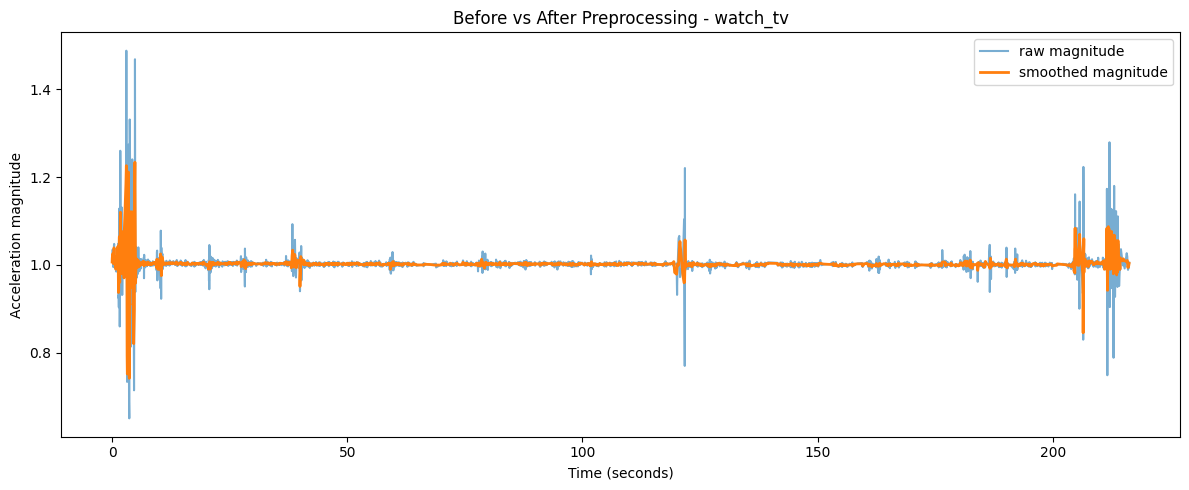

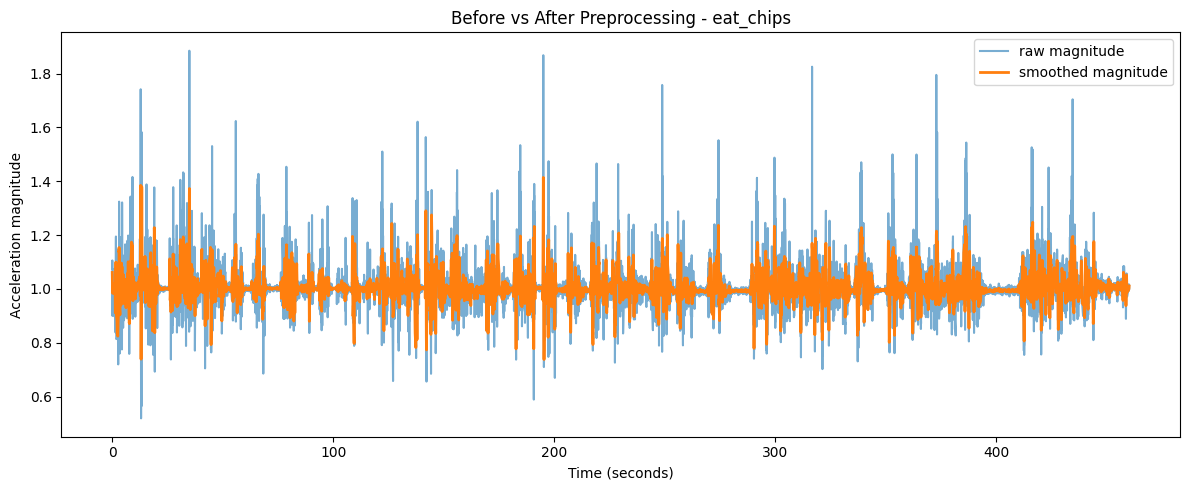

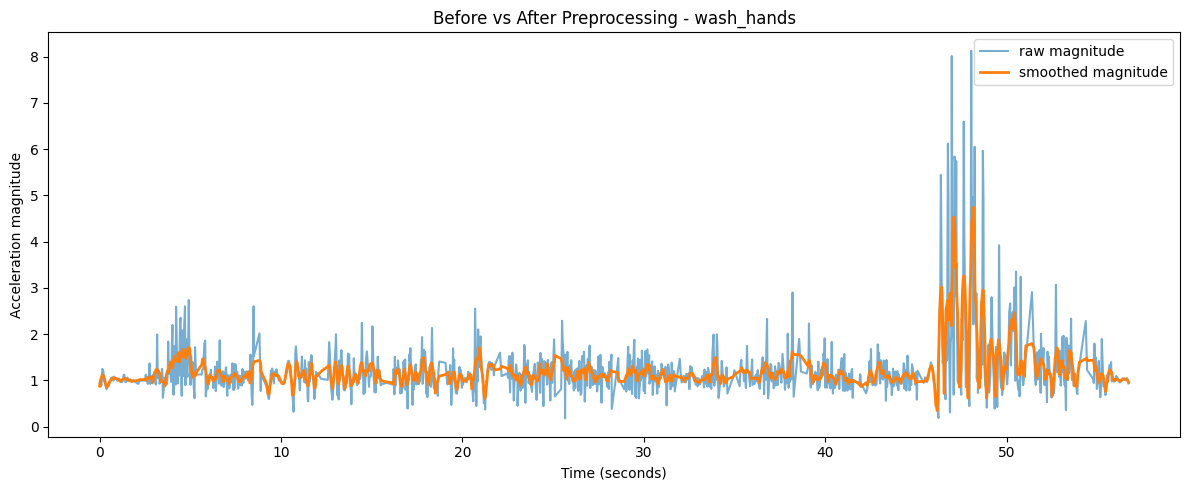

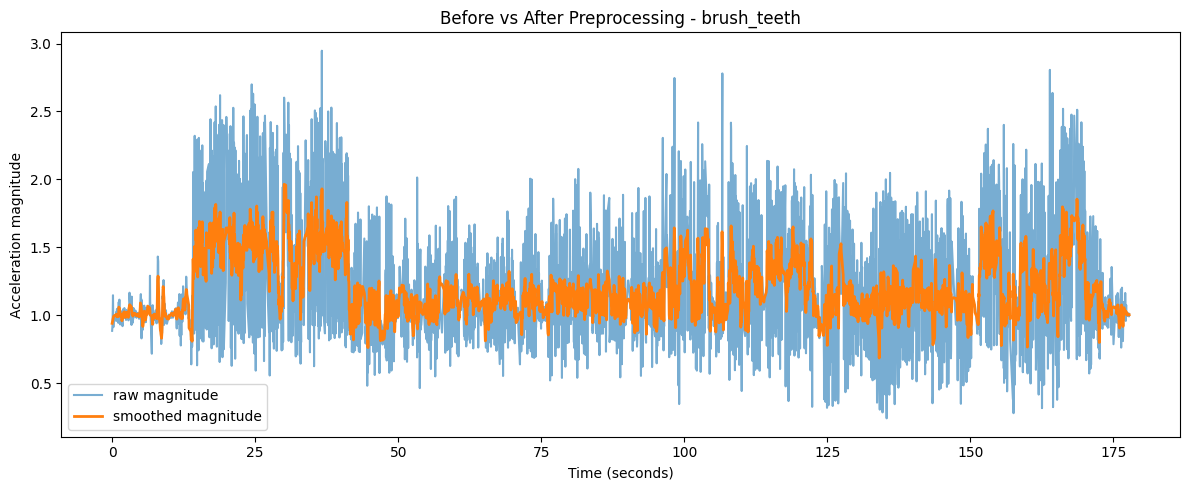

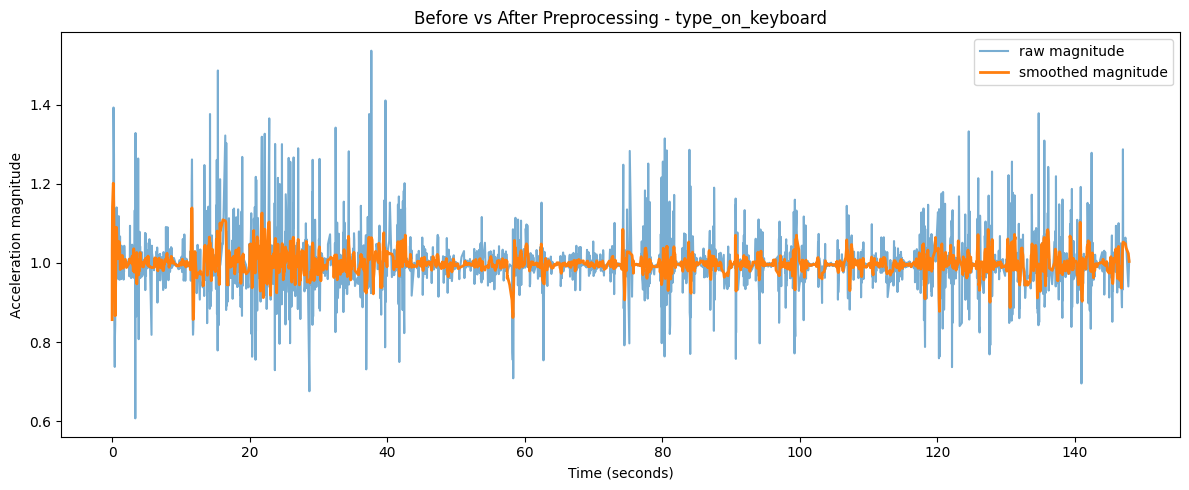

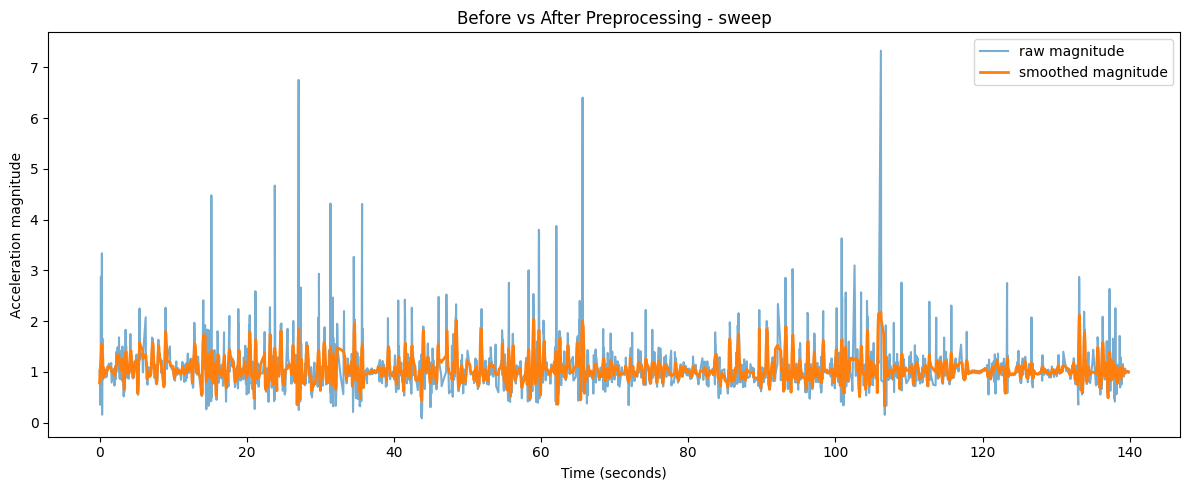

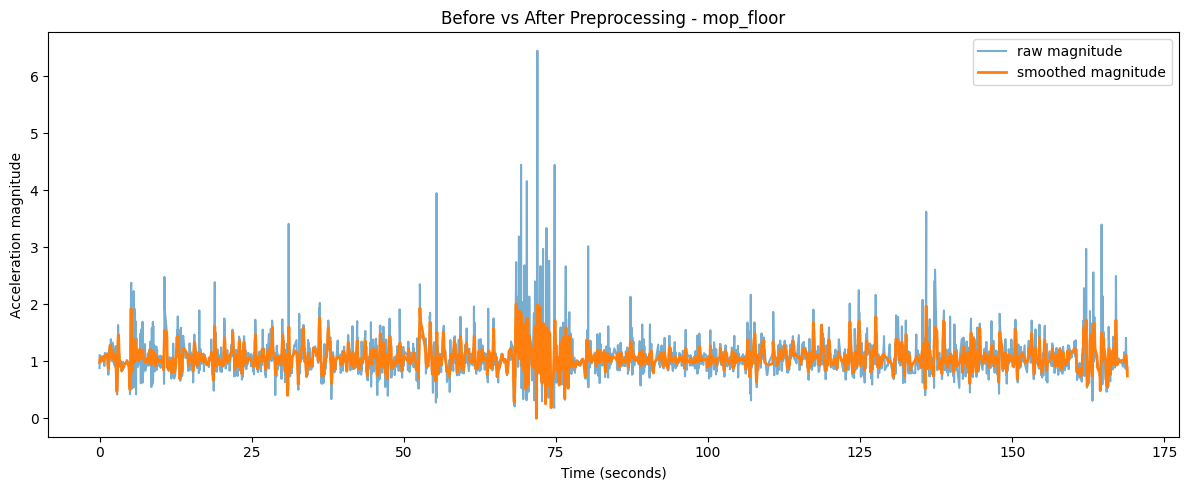

In [53]:
#=================================
# Visualizing raw accelerometer data
#=================================
def estimate_sampling_rate(df):
    dt = np.diff(df["time_sec"])
    dt = dt[dt > 0]  # Remove negative values
    fs = 1 / np.mean(dt)
    return fs

def preprocess_signal(df):
    df = df.copy()

    # Sort by time
    df = df.sort_values("time_sec").reset_index(drop=True)

    # Interpolate missing values
    for col in ["x", "y", "z", "magnitude"]:
        if df[col].isna().sum() > 0:
            df[col] = df[col].interpolate(method="linear").bfill().ffill()

    # Smooth signal
    fs = estimate_sampling_rate(df)
    win = int(fs * 0.5)
    if win % 2 == 0:
        win += 1
    win = max(5, win)
    if win >= len(df):
        win = len(df) - 1 if len(df) % 2 == 0 else len(df)
        
    df["x_smooth"] = savgol_filter(df["x"], window_length=win, polyorder=2)
    df["y_smooth"] = savgol_filter(df["y"], window_length=win, polyorder=2)
    df["z_smooth"] = savgol_filter(df["z"], window_length=win, polyorder=2)
    df["mag_smooth"] = savgol_filter(df["magnitude"], window_length=win, polyorder=2)
    return df

def load_acc_file(filepath):
    df = pd.read_csv(filepath, header=None, names=["timestamp", "x", "y", "z"])

    # Convert timestamp to relative seconds
    df["time_sec"] = (df["timestamp"] - df["timestamp"].iloc[0]) / 1000.0
    
    # Movement magnitude
    df["magnitude"] = np.sqrt(df["x"]**2 + df["y"]**2 + df["z"]**2)
    return df

files = {
    "watch_tv": path + "/user1/1468360517106-acc-watch_tv.txt",
    "eat_chips": path + "/user1/1468367368314-acc-eat_chips.txt",
    "wash_hands": path + "/user1/1468367865103-acc-wash_hands.txt",
    "brush_teeth": path + "/user1/1468379023854-acc-brush_teeth.txt",
    "type_on_keyboard": path + "/user1/1468683416878-acc-type_on_keyboard.txt",
    "sweep": path + "/user1/1468962546058-acc-sweep.txt",
    "mop_floor": path + "/user1/1468962874857-acc-mop_floor.txt"
}

raw_data = {label: preprocess_signal(load_acc_file(path)) for label, path in files.items()}

def plot_before_after(df, title):
    plt.figure(figsize=(12, 5))
    plt.plot(df["time_sec"], df["magnitude"], label="raw magnitude", alpha=0.6)
    plt.plot(df["time_sec"], df["mag_smooth"], label="smoothed magnitude", linewidth=2)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Acceleration magnitude")
    plt.title(f"Before vs After Preprocessing - {title}")
    plt.legend()
    plt.tight_layout()
    plt.show()

for label, df in raw_data.items():
    plot_before_after(df, label)

We can see that raw accelerometer signals are often noisy, uneven, and harder to intepret directly. Small spikes, sensor jitter, and minor recordign inconsistencies can hide the real motion pattern of an activity. By converting timestamps to consistent time scale, filling missing values, and smoothing the signal, the data becomes cleaner and more reliable for analysis. This makes it easier to see meaningful differences between activities.

__4. Windowing Strategies__

In [57]:
window_sizes = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

def normalized_energy(x):
    x = np.asarray(x)
    return np.mean(x**2)

results = []

for label, df in raw_data.items():
    fs = estimate_sampling_rate(df)
    signal = df["mag_smooth"].values 
    n_samples = len(signal)

    # Iterate over window sizes
    for w in window_sizes:
        window_size = int(w * fs)
        step_size = int(window_size * 0.5)   # 50% overlap

        window_energies = []

        # Compute window energies
        if window_size > 1 and step_size > 0 and n_samples >= window_size:
            for start in range(0, n_samples - window_size + 1, step_size):
                window = signal[start:start + window_size]
                window_energies.append(normalized_energy(window))

        # Compute CV
        if len(window_energies) > 0:
            mean_window_energy = np.mean(window_energies)
            std_window_energy = np.std(window_energies)
            cv_energy = std_window_energy / mean_window_energy if mean_window_energy != 0 else np.nan
        else:
            mean_window_energy = np.nan
            std_window_energy = np.nan
            cv_energy = np.nan

        results.append({
            "activity": label,
            "window_sec": w,
            "window_samples": window_size,
            "num_windows": len(window_energies),
            "cv_energy": cv_energy
        })

energy_results = pd.DataFrame(results)

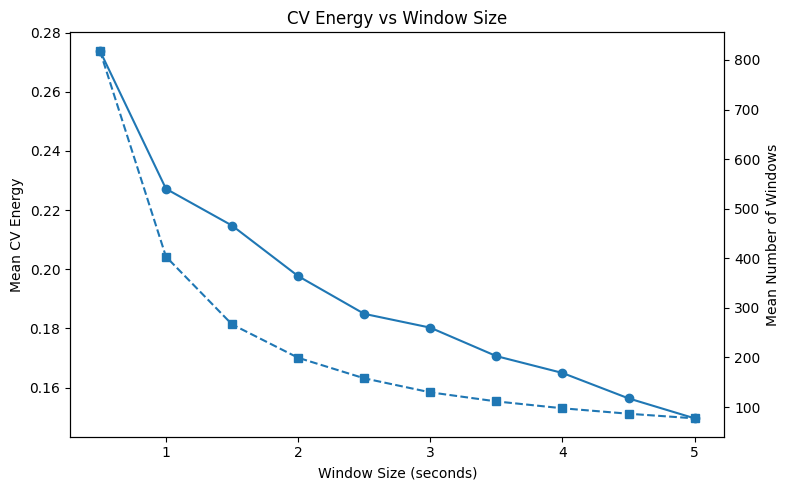

,window_sec,cv_energy,num_windows
0,0.5,0.2739,818.5714
1,1.0,0.2272,403.2857
2,1.5,0.2148,266.7143
3,2.0,0.1977,199.4286
4,2.5,0.1850,158.0000
5,3.0,0.1803,129.7143
6,3.5,0.1707,111.4286
7,4.0,0.1650,97.5714
8,4.5,0.1564,86.5714
9,5.0,0.1496,77.2857


In [59]:
summary_plot = (
    energy_results.groupby("window_sec")[["cv_energy", "num_windows"]]
    .mean()
    .reset_index()
)

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(summary_plot["window_sec"], summary_plot["cv_energy"], marker="o")
ax1.set_xlabel("Window Size (seconds)")
ax1.set_ylabel("Mean CV Energy")
ax1.set_title("CV Energy vs Window Size")

ax2 = ax1.twinx()
ax2.plot(summary_plot["window_sec"], summary_plot["num_windows"], marker="s", linestyle="--")
ax2.set_ylabel("Mean Number of Windows")

plt.tight_layout()
plt.show()

display(summary_plot.round(4))

Different window sizes from 0.5 to 5.0 seconds were tested using 50% overlap. For each window, normalized energy was computed. The coefficient of variation of window energy was used to measure stability. CV is defined as the standard deviation divided by the mean. Lower CV means the window energies are more similar to one another, so segmentation is more stable. A higher CV means activity is more variable across windows.

As window size increases, CV generally decreases for all activities. This mean larger windows produce more stable energy measurements. However, increasing window size also reduces number of windows available for analysis. Therefore, window size at 2 seconds is reasonable, since it reduces CV significantly while keeping enough windows for analysis.

__5. Feature Extraction and Analysis__

__6. Modeling__

__7. Advanced Modeling & Evaluation__

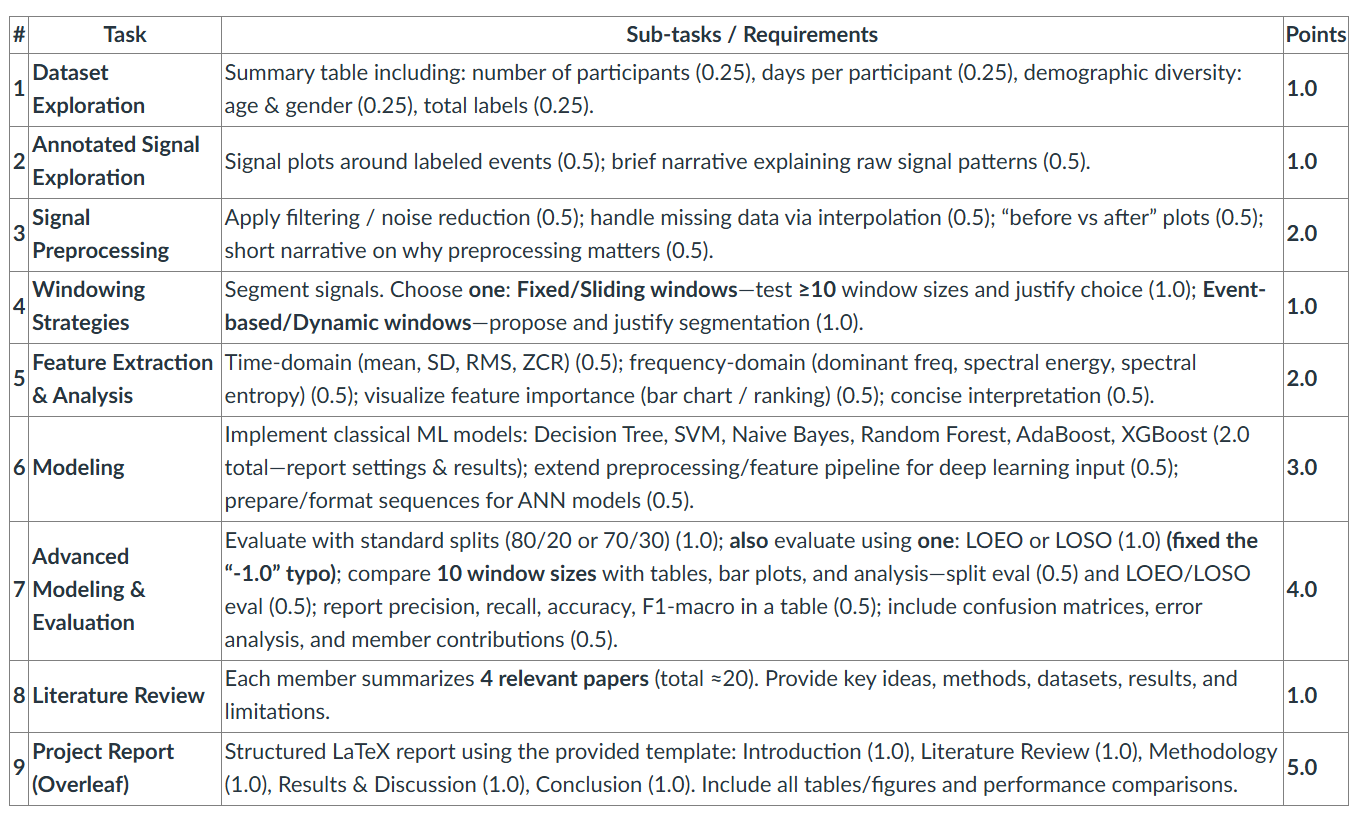